<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan13_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Langkah 1. Import Library
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

np.random.seed(42)

Langkah 2. Generate & Eksplorasi Dataset Non-Linear

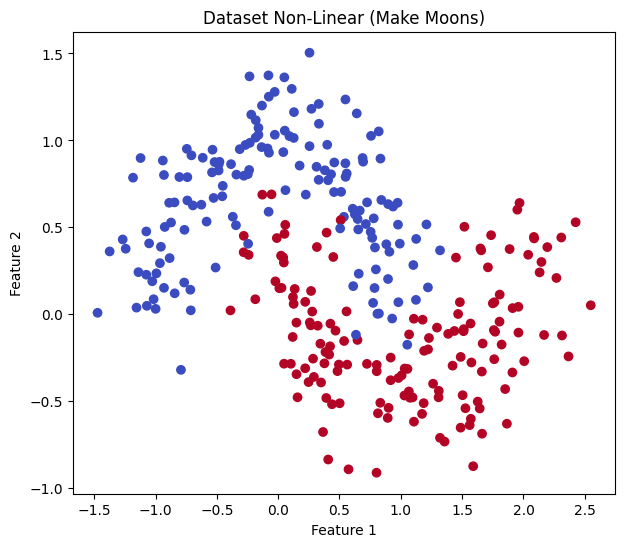

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Dataset Non-Linear (Make Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Langkah 3. Bangun Neural Network

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = Sequential([

    Dense(
        16,
        activation='relu',
        input_shape=(2,)
    ),

    Dense(
        8,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Langkah 4. Training Model

In [4]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,

    validation_split=0.2,

    verbose=1

)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.5990 - loss: 0.6581 - val_accuracy: 0.6875 - val_loss: 0.6670
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6667 - loss: 0.6496 - val_accuracy: 0.7083 - val_loss: 0.6592
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7031 - loss: 0.6411 - val_accuracy: 0.7083 - val_loss: 0.6517
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7135 - loss: 0.6334 - val_accuracy: 0.7083 - val_loss: 0.6439
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7188 - loss: 0.6258 - val_accuracy: 0.7292 - val_loss: 0.6361
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7292 - loss: 0.6179 - val_accuracy: 0.7292 - val_loss: 0.6282
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7344 - loss: 0.6099 - val_accuracy: 0.7292 - val_loss: 0.6198
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7292 - loss: 0.6017 - val_accuracy: 0.7500 - val_loss: 0.6110

Langkah 5. Evaluasi Model

Akurasi : 0.900


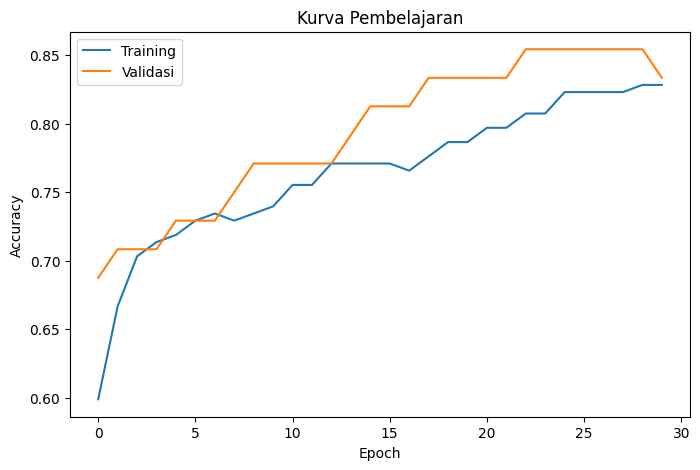

In [5]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Akurasi : {accuracy:.3f}")

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validasi'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Kurva Pembelajaran")

plt.legend()

plt.show()

Langkah 6. Dataset Analisis Sentimen

In [6]:
ulasan = [

"Barangnya bagus banget, pengiriman cepat",
"Kualitas jelek, tidak sesuai deskripsi",
"Sangat puas, akan beli lagi",
"Kecewa, barang rusak saat sampai",
"Recommended, harga sesuai kualitas",
"Buruk sekali, tidak sesuai ekspektasi",
"Pelayanan ramah dan cepat",
"Packing sangat rapi",
"Produk berkualitas tinggi",
"Sangat memuaskan",
"Barang original",
"Pengiriman sangat cepat",
"Harga murah",
"Respon penjual baik",
"Barang sesuai foto",
"Saya sangat puas",
"Kualitas luar biasa",
"Top banget",
"Sangat direkomendasikan",
"Terima kasih",

"Produk mengecewakan",
"Barang cacat",
"Packing rusak",
"Tidak akan beli lagi",
"Sangat buruk",
"Pengiriman lambat",
"Respon penjual lama",
"Kualitas jelek",
"Tidak sesuai foto",
"Barang palsu",
"Harga terlalu mahal",
"Sangat kecewa",
"Tidak rekomendasi",
"Produk rusak",
"Pelayanan buruk",
"Tidak memuaskan",
"Banyak cacat",
"Tidak layak beli",
"Sangat jelek",
"Kecewa berat"

]

label = [

1,0,1,0,1,0,
1,1,1,1,1,
1,1,1,1,1,
1,1,1,1,

0,0,0,0,0,
0,0,0,0,0,
0,0,0,0,0,
0,0,0,0,0

]

Langkah 7. TF-IDF

In [7]:
tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik :",
      len(tfidf.get_feature_names_out()))

print(tfidf.get_feature_names_out()[:20])

Jumlah kata unik : 58
['akan' 'bagus' 'baik' 'banget' 'banyak' 'barang' 'barangnya' 'beli'
 'berat' 'berkualitas' 'biasa' 'buruk' 'cacat' 'cepat' 'dan' 'deskripsi'
 'direkomendasikan' 'ekspektasi' 'foto' 'harga']


Langkah 8. Logistic Regression

In [8]:
Xt_train, Xt_test, yt_train, yt_test = train_test_split(

    X_text,

    label,

    test_size=0.2,

    random_state=42

)

model_sentimen = LogisticRegression()

model_sentimen.fit(
    Xt_train,
    yt_train
)

akurasi = model_sentimen.score(
    Xt_test,
    yt_test
)

print(f"Akurasi Sentimen : {akurasi:.3f}")

kalimat_baru = [

    "Pelayanan sangat memuaskan dan ramah"

]

prediksi = model_sentimen.predict(

    tfidf.transform(kalimat_baru)

)

print(

    "Positif"

    if prediksi[0]==1

    else

    "Negatif"

)

Akurasi Sentimen : 0.375
Negatif


# Kesimpulan

Berdasarkan hasil praktikum, Artificial Neural Network berhasil mempelajari pola pada dataset non-linear menggunakan activation function ReLU dan Sigmoid, sehingga mampu melakukan klasifikasi dengan akurasi yang baik. Kurva pembelajaran menunjukkan bahwa model dapat belajar secara bertahap selama proses training. Selain itu, pada bagian Natural Language Processing, metode TF-IDF berhasil mengubah data teks menjadi bentuk numerik yang dapat diproses oleh algoritma Logistic Regression untuk melakukan analisis sentimen. Model mampu mengklasifikasikan ulasan menjadi sentimen positif dan negatif dengan baik berdasarkan kata-kata yang terdapat pada ulasan. Dengan demikian, praktikum ini menunjukkan penerapan dasar Deep Learning untuk klasifikasi non-linear serta Natural Language Processing untuk analisis sentimen menggunakan pendekatan machine learning.